# Screen-attack PAD — analysis of global features

This notebook walks investigation of global features in order. Features are cached to
`features_cache.csv` on first run, so re-running is fast.

### Where it lands

| finding | evidence |
|---|---|
| Resolution was a severe confound | all bona fide 1024², all 23 attacks larger (21 distinct sizes) — fixed by resizing everything to 1024 by 1024 |
| Edge *orientation* is the best new feature | attacks missed: 7/23 → 6/23 (edge strength) → **4/23 (orientation)** |
| Mean/std were the wrong summary | 3 features have std > mean; switched to median/IQR and Cliff's delta |
| Rank-based scaling changes the winner | LogisticRegression 5/23 → **1/23** with `QuantileTransformer`, overtaking RandomForest |
| A *linear* model wins | complexity isn't earning its keep — good news for shipping and for interpretability |

### What is still uncertain

- The winner is **supervised**, so it sees attack labels and may have learned *these 23*
  rather than screen recapture in general.
- **One-class models are much worse** (9–12 missed), which contradicts the prior
  expectation that they'd generalise better.
- Every attack-side number has a wide interval: even 1/23 has a 95% CI of [0.00, 0.22].

> ### The 23 attacks are all the same device

> There is **no diversity of the attack class**, not 23
> independent samples. Consequences:
>
> - Nothing here evidences generalisation to a different screen, phone, tablet or print
>   medium.
> - Unable to test the effectiveness of the model on specific attack vectors or leave-one-out assessments
> - A *supervised* model fitted to 23 samples of one device is at real risk of learning
>   that device rather than screen recapture in general. The one-class models were included
>   partly to hedge against this; they underperform, so the hedge is weak.

## 1. Setup

In [1]:
import glob
from pathlib import Path

import cv2  # image IO and every classical CV operator used here
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from features import (
    # image quality -- Galbally et al., IEEE TIP 2014
    sharpness, noise_estimate, contrast,
    # colour -- Hasler & Suesstrunk 2003; Boulkenafet et al. 2015/2016
    colorfulness, chroma_std,
    # spot lighting / glare (an artefact seen directly in the data)
    specular_highlight_ratio, glare_blob_count, glare_largest_blob_area_ratio,
    # framing / background leakage past the presentation surface
    long_line_ratio,
    # attempting to catch moire-like effect on screen -- Patel, Han & Jain, ICB 2015
    high_frequency_energy_ratio,
    # edge strength and edge orientation
    prewitt_energy, orientation_entropy, perpendicular_energy_ratio,
)

BONA_DIR, SCREEN_DIR = "data/Bonafide", "data/Screens"
CACHE = Path("features_cache.csv")
FORCE_RECOMPUTE = False  # set True after changing anything in features.py

bona_paths = sorted(glob.glob(f"{BONA_DIR}/*.png"))
screen_paths = sorted(glob.glob(f"{SCREEN_DIR}/*.png"))
print(f"{len(bona_paths)} bona fide, {len(screen_paths)} screens")

N_SCREEN = len(screen_paths)
N_BONA = len(bona_paths)

1000 bona fide, 23 screens


## 2. The first thing to check: is there anything trivial?


In [2]:
def image_size(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    return img.shape[:2]


bona_sizes = np.array([image_size(p) for p in bona_paths])
screen_sizes = np.array([image_size(p) for p in screen_paths])

print("bona fide :", len(np.unique(bona_sizes, axis=0)), "distinct size(s);",
      f"h {bona_sizes[:,0].min()}-{bona_sizes[:,0].max()},",
      f"w {bona_sizes[:,1].min()}-{bona_sizes[:,1].max()}")
print("screens   :", len(np.unique(screen_sizes, axis=0)), "distinct size(s);",
      f"h {screen_sizes[:,0].min()}-{screen_sizes[:,0].max()},",
      f"w {screen_sizes[:,1].min()}-{screen_sizes[:,1].max()}")

bona fide : 1 distinct size(s); h 1024-1024, w 1024-1024
screens   : 21 distinct size(s); h 1741-5712, w 1723-4284


**Every bona fide image is exactly 1024×1024; every attack is larger, across 21 distinct
sizes.** A classifier thresholding on image dimensions alone would score near-perfectly
while learning nothing whatsoever about presentation attacks, and would collapse the
moment the hidden set was captured differently.

Several features are directly sensitive to absolute pixel dimensions (`sharpness`,
`line_ratio`, `hf_energy`, the glare counts), so this had to be neutralised before
anything else. Everything is resized to 1024×1024.

In [3]:
def load(path, size=1024):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    # INTER_AREA is OpenCV's documented choice for shrinking - it averages over each
    # output pixel's source region rather than sampling, which limits aliasing. That
    # matters here because aliasing is itself one of the artefacts we measure (hf_energy).
    bgr = cv2.resize(bgr, (size, size), interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

## 3. Look at the data

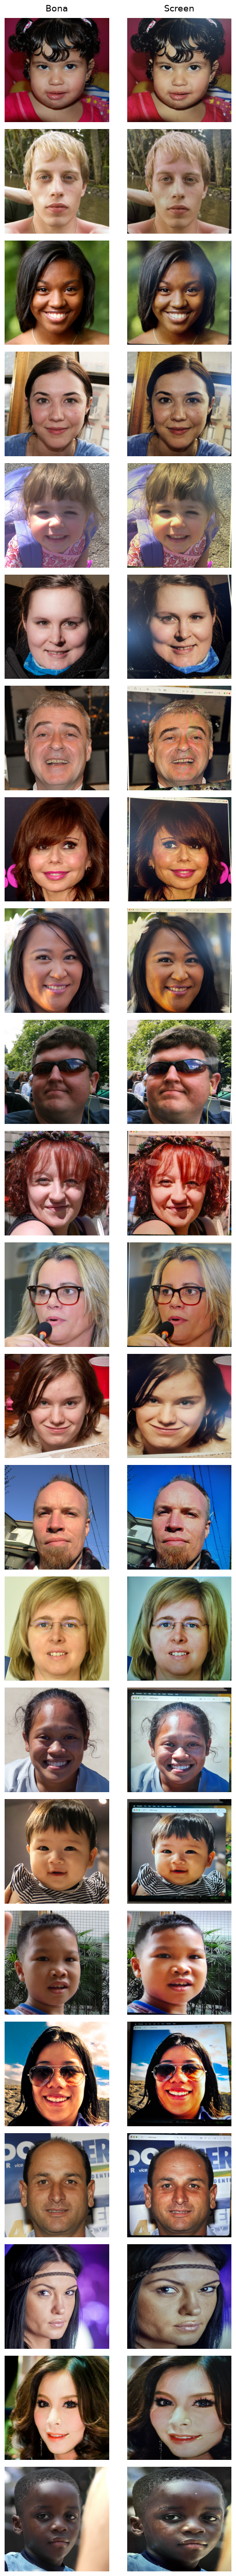

In [4]:
fig, axes = plt.subplots(N_SCREEN, 2, figsize=(6, 56))
axes[0, 0].set_title("Bona", fontsize=14, pad=10)
axes[0, 1].set_title("Screen", fontsize=14, pad=10)

for i, ax in enumerate(axes):
    rgb, _ = load(bona_paths[i])
    ax[0].imshow(rgb)
    ax[0].axis("off")

    rgb, _ = load(screen_paths[i])
    ax[1].imshow(rgb)
    ax[1].axis("off")

plt.tight_layout()

We can see aliasing and non-uniform illumination, GUIs/borders, and reflections in the screen.

## 4. Features

Eleven features in here, each targeting a cue with a physical reason to differ between a direct
capture and a recapture of a display. Formulas live in `features.py` with unit tests.

Two families were tried and dropped, both documented below:
`sobel_energy`/`scharr_energy` (synonyms of `prewitt_energy`) and `contrast`/`glare_n`
(no signal). see `features.py`.

In [5]:
FEATURES = {
    # --- image quality: a recapture passes through a second camera ------------
    "sharpness": lambda rgb, gray: sharpness(gray),          # variance of Laplacian
    "noise": lambda rgb, gray: noise_estimate(gray),         # Immerkaer 1996
    # --- colour: displays have a narrower, differently-biased gamut than skin -
    "colorfulness": lambda rgb, gray: colorfulness(rgb),     # Hasler & Suesstrunk 2003
    "chroma_std": lambda rgb, gray: chroma_std(rgb),
    # --- glare: flat glossy glass reflects light differently from skin --------
    "specular_ratio": lambda rgb, gray: specular_highlight_ratio(rgb),
    "glare_area": lambda rgb, gray: glare_largest_blob_area_ratio(rgb),
    # --- framing: a bezel or paper edge is a long straight line ---------------
    "line_ratio": lambda rgb, gray: long_line_ratio(gray),
    # --- moire: screen pixel grid beating against the sensor grid -------------
    "hf_energy": lambda rgb, gray: high_frequency_energy_ratio(gray),  # Patel et al. 2015
    # --- edge strength --------------------------------------------------------
    "prewitt_energy": lambda rgb, gray: prewitt_energy(gray),
    # --- edge ORIENTATION: the only features measuring direction, not strength.
    # A bezel concentrates edges at two perpendicular angles; a face spreads them
    # across all angles. These turned out to be the most valuable addition (§8).
    "orientation_entropy": lambda rgb, gray: orientation_entropy(gray),
    "perpendicular_ratio": lambda rgb, gray: perpendicular_energy_ratio(gray),
}
print(f"{len(FEATURES)} features")

11 features


In [6]:
def feature_row(path, label):
    rgb, gray = load(path)  # one decode per image, not one per feature
    row = {name: fn(rgb, gray) for name, fn in FEATURES.items()}
    row["label"], row["path"] = label, path
    return row


if CACHE.exists() and not FORCE_RECOMPUTE:
    df = pd.read_csv(CACHE)
    missing = [f for f in FEATURES if f not in df.columns]
    if missing:  # cache predates a feature -- recompute rather than half-analyse
        raise RuntimeError(f"cache is missing {missing}; set FORCE_RECOMPUTE = True")
    print(f"loaded {len(df)} rows from {CACHE}")
else:
    rows = [feature_row(p, "bonafide") for p in bona_paths]
    rows += [feature_row(p, "screen") for p in screen_paths]
    df = pd.DataFrame(rows)
    df.to_csv(CACHE, index=False)
    print(f"computed and cached {len(df)} rows -> {CACHE}")

y = (df["label"] == "screen").to_numpy().astype(int)  # 1 = attack, used throughout
df

loaded 1023 rows from features_cache.csv


,sharpness,noise,contrast,colorfulness,chroma_std,specular_ratio,glare_n,glare_area,line_ratio,hf_energy,prewitt_energy,orientation_entropy,perpendicular_ratio,label,path
0,67.047615,0.771200,47.960845,63.845396,23.063350,0.000038,12.0,0.000012,0.124912,0.689013,719.083983,0.994457,0.080333,bonafide,data/Bonafide/00962.png
1,57.856889,0.504044,60.847418,37.726433,11.931058,0.022628,361.0,0.003963,0.098543,0.641839,757.214085,0.989251,0.080355,bonafide,data/Bonafide/00998.png
2,168.091756,1.193992,52.152313,57.419254,21.482700,0.001950,36.0,0.001176,0.117776,0.752205,779.348234,0.984969,0.075442,bonafide,data/Bonafide/01012.png
3,87.852484,0.868776,60.556906,52.298191,20.005397,0.039929,132.0,0.033299,0.199950,0.664587,806.112287,0.987678,0.093622,bonafide,data/Bonafide/08794.png
4,540.135976,1.390449,47.695433,42.123337,17.651116,0.040283,1571.0,0.008137,0.176465,0.856217,4498.481758,0.993273,0.066685,bonafide,data/Bonafide/10673.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018,227.453510,1.098820,79.136785,88.300378,40.570537,0.021916,255.0,0.005133,0.225255,0.706979,3328.027241,0.985316,0.099565,screen,data/Screens/11040.png
1019,749.182026,4.736824,64.653721,64.900914,28.879975,0.040547,975.0,0.025822,0.321098,0.734599,2524.022296,0.966783,0.166659,screen,data/Screens/11053.png
1020,919.017814,7.544668,58.304295,40.565115,18.907257,0.000000,0.0,0.000000,0.057840,0.722823,438.100864,0.995967,0.075780,screen,data/Screens/11099.png
1021,1068.584331,8.375728,64.505020,29.407637,11.765838,0.000000,0.0,0.000000,0.067269,0.684810,291.438749,0.981032,0.084762,screen,data/Screens/11117.png


## 5. Summarising the features

I originally viewed this with mean and std, but both statistics are highly sensitive to outliers.
For several of these features that isn't hypothetical — `glare_area` and `specular_ratio`
have a std *larger* than their mean, which is impossible for a roughly-Gaussian
non-negative quantity and is a signature of severe right skew.

So: median and IQR, plus a `tail_ratio` diagnostic.

**Reading `tail_ratio`:** it's `std ÷ (1.4826 × MAD)` - a fragile spread estimate divided
by a robust one. Both estimate σ, and they agree when the data is well behaved.

- **≈ 1** — trustworthy; mean/std would have been fine
- **>> 1** — std is inflated by a handful of extreme values; the bulk is far tighter

`glare_area` comes in around 18 and `specular_ratio` around 12. Quoting a mean ± std for
those describes a population that barely exists. This also has a concrete modelling
consequence, not just a presentational one: `StandardScaler` divides by std, so for
`glare_area` it divides by a number ~18× larger than the actual spread of typical data,
compressing almost every image into a sliver while the outliers occupy the range. That is
exactly the mechanism that hurts distance-based one-class models — see section 11.

In [7]:
def robust_summary(frame, features):
    bona = frame[frame["label"] == "bonafide"]
    screen = frame[frame["label"] == "screen"]
    rows = {}
    for f in features:
        b, s = bona[f], screen[f]
        # 1.4826 * MAD is a consistent estimator of sigma for Gaussian data, so it is
        # directly comparable to std - and the ratio is a free skew diagnostic:
        # ~1 means well-behaved, >>1 means std is being manufactured by a few outliers.
        mad_b = 1.4826 * (b - b.median()).abs().median()
        rows[f] = {
            "bona_median": b.median(),
            "bona_iqr": b.quantile(0.75) - b.quantile(0.25),
            "screen_median": s.median(),
            "screen_iqr": s.quantile(0.75) - s.quantile(0.25),
            "tail_ratio": b.std() / mad_b if mad_b > 0 else np.nan,
        }
    return pd.DataFrame(rows).T


robust_summary(df, list(FEATURES)).round(3)

,bona_median,bona_iqr,screen_median,screen_iqr,tail_ratio
sharpness,108.490,104.320,395.243,626.457,2.381
noise,0.896,0.485,1.753,1.994,1.168
colorfulness,45.334,15.998,51.808,13.345,1.310
chroma_std,16.862,6.631,21.416,3.186,1.356
specular_ratio,0.004,0.031,0.001,0.017,11.684
glare_area,0.002,0.015,0.000,0.004,17.905
line_ratio,0.104,0.049,0.223,0.169,1.410
hf_energy,0.716,0.067,0.759,0.066,0.997
prewitt_energy,865.767,643.553,1459.498,1827.263,1.671
orientation_entropy,0.993,0.008,0.981,0.017,2.387


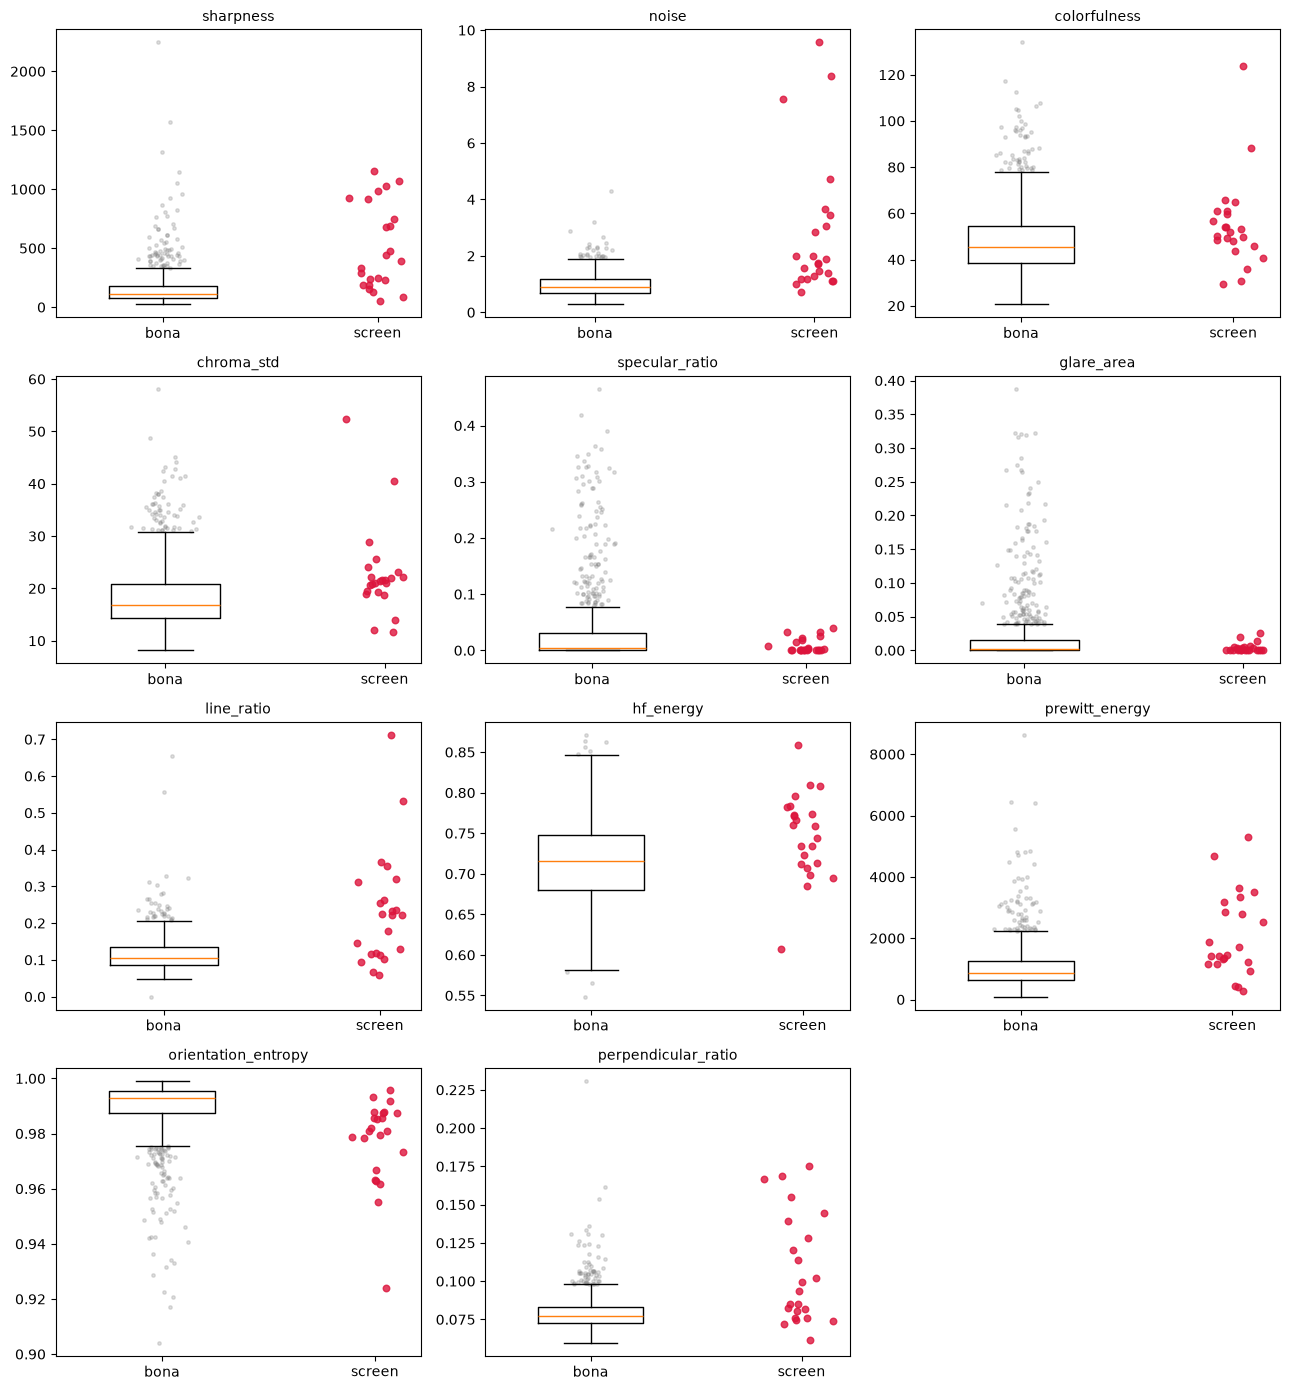

In [8]:
# With only 23 attacks we can plot every single one rather than summarising them.
# This separates three cases any summary statistic conflates: a genuine location
# shift, a few extreme values doing all the work, or no separation at all.
rng_jitter = np.random.default_rng(0)

fig, axes = plt.subplots(4, 3, figsize=(13, 14))
for ax, f in zip(axes.ravel(), FEATURES):
    b = df.loc[df["label"] == "bonafide", f]
    s = df.loc[df["label"] == "screen", f]
    ax.boxplot([b], positions=[0], widths=0.5, showfliers=False)
    q1, q3 = b.quantile(0.25), b.quantile(0.75)
    outliers = b[(b > q3 + 1.5 * (q3 - q1)) | (b < q1 - 1.5 * (q3 - q1))]
    ax.scatter(rng_jitter.normal(0, 0.05, len(outliers)), outliers, s=6, alpha=0.25, color="grey")
    ax.scatter(rng_jitter.normal(1, 0.06, len(s)), s, s=22, alpha=0.8, color="crimson")
    ax.set_xticks([0, 1], ["bona", "screen"])
    ax.set_title(f, fontsize=10)
for ax in axes.ravel()[len(FEATURES):]:
    ax.axis("off")
plt.tight_layout()

## 6. Which features separate the classes?

Given the skew above, the primary measure has to be rank-based:

- **Cliff's delta** — P(screen > bona) − P(bona > screen), bounded [−1, 1]. Purely ordinal,
  so skew and outliers can't distort it. It relates to AUC exactly: **δ = 2·AUC − 1**, so
  the AUC we already compute *is* the robust effect size on another scale.
- **Cohen's d** — kept only as a *diagnostic*. Under normality, d implies a specific δ
  (δ = 2Φ(d/√2) − 1). Where implied and actual diverge, normality is failing and any
  mean/std reading of that feature is being driven by its tail.

Signs are kept: a feature separating in the *inverted* direction is just as useful, since a
model can learn the sign. Ranking uses |δ|.

In [9]:
from scipy.stats import norm
from sklearn.metrics import roc_auc_score


def cohens_d(frame, feature):
    """Parametric effect size -- kept as a skew diagnostic, not a headline."""
    b = frame.loc[frame["label"] == "bonafide", feature]
    s = frame.loc[frame["label"] == "screen", feature]
    pooled = np.sqrt(((len(b) - 1) * b.var(ddof=1) + (len(s) - 1) * s.var(ddof=1))
                     / (len(b) + len(s) - 2))
    return (s.mean() - b.mean()) / pooled


# Scored over every numeric column in the cache, including the two features (glare_n and contrast)
# that were dropped - so the evidence for dropping them is visible rather than asserted.
SCORED = [c for c in df.columns if c not in ("label", "path")]

sep = pd.DataFrame({"auc": {f: roc_auc_score(y, df[f]) for f in SCORED}})
sep["cliffs_delta"] = 2 * sep["auc"] - 1  # exact rescaling of AUC -- nothing extra to fit
sep["cohens_d"] = pd.Series({f: cohens_d(df, f) for f in SCORED})
sep["delta_if_normal"] = 2 * norm.cdf(sep["cohens_d"] / np.sqrt(2)) - 1
sep["normality_gap"] = (sep["delta_if_normal"] - sep["cliffs_delta"]).abs()
sep["strength"] = sep["cliffs_delta"].abs()
sep["kept"] = [f in FEATURES for f in sep.index]
sep.sort_values("strength", ascending=False).round(3)

,auc,cliffs_delta,cohens_d,delta_if_normal,normality_gap,strength,kept
noise,0.875,0.750,3.422,0.984,0.234,0.750,True
sharpness,0.848,0.695,2.177,0.876,0.181,0.695,True
orientation_entropy,0.197,-0.607,-1.065,-0.549,0.058,0.607,True
line_ratio,0.788,0.576,2.265,0.891,0.315,0.576,True
prewitt_energy,0.759,0.518,1.310,0.646,0.127,0.518,True
perpendicular_ratio,0.745,0.490,2.110,0.864,0.375,0.490,True
chroma_std,0.705,0.410,0.674,0.367,0.043,0.410,True
hf_energy,0.689,0.377,0.658,0.358,0.019,0.377,True
glare_area,0.343,-0.314,-0.341,-0.191,0.123,0.314,True
colorfulness,0.631,0.262,0.431,0.239,0.023,0.262,True


**What this established.**

`noise` and `sharpness` lead, followed by `orientation_entropy` - an encouraging result,
since orientation was added on a physical hypothesis (bezels concentrate edges at
perpendicular angles) rather than by search.

**Dropped on this evidence:** `contrast` (δ ≈ −0.03) and `glare_n` (δ ≈ 0.09) - no signal.
They are not in the `FEATURES` dict above.

**Kept despite weak scores:** `specular_ratio` and `glare_area`. Both separate in the
*inverted* direction - screens show *less* glare - which contradicts the spot-lighting
story and may be a capture-distance confound (bona fide are close-up faces with skin
specularity; screens are photographed further back). They are retained because pruning
hard on 23 attacks is itself a form of overfitting, but section 13 checks whether they are
load-bearing.

## 7. Redundancy: are any features measuring the same thing twice?

Worth asking before trusting a count of features as a count of evidence. Spearman corr rather than Pearson, because of skew.

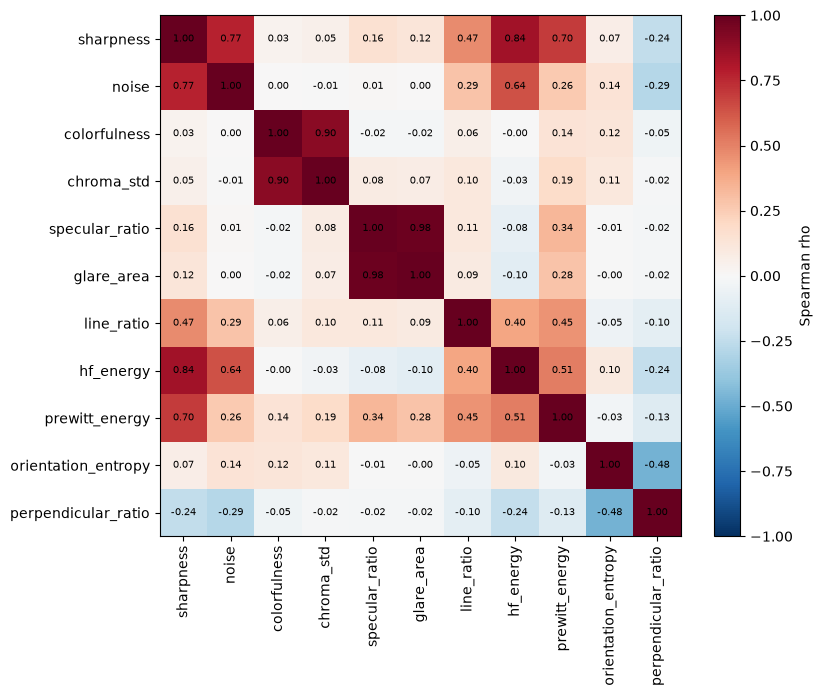

In [10]:
corr = df[list(FEATURES)].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, label="Spearman rho")
plt.tight_layout()

This is what removed two features. `sobel_energy`, `scharr_energy` and `prewitt_energy` are
all "variance of gradient magnitude" with different kernels, and they came back at rank
correlation ≈ 1.0 with each other. Their `tail_ratio`
values were near-identical too (1.686 / 1.677 / 1.671), which is corroborating evidence
from a completely different statistic.

`prewitt_energy` was kept as it had marginally the lowest correlation. Reporting three
correlated features as three pieces of evidence would have overstated the feature set.

## 8. Models and  protocol

Protocol first, because with 23 attacks it's easier to produce a good-looking number than a
true one:

- **Everything is scored out-of-fold.** 5-fold stratified CV; each image is scored only by a
  model that never saw it.
- **One-class models are fitted on bona fide only** (the attack-free part of each training
  fold). Supervised models see both classes. Identical folds and metrics either way.
  The one-class framing is the one that generalises to *unseen* attack types which matters because 23 attacks cannot represent the space of attack instruments used in the wild.
- **Thresholds come from bona fide scores only**, never from attack scores, so APCER is an
  honest held-out number rather than a tuned one.
- **APCER/BPCER per ISO/IEC 30107-3**, (and on iProov's website!) not accuracy - which is meaningless at 43:1.
- **Exact Clopper-Pearson intervals.** At n=23 one attack flipping moves APCER by 4.3
  points, and the interval should say so.

Both a linear and a non-linear model appear in each family, so we can tell whether any gain
comes from non-linearity or merely from seeing labels.

In [11]:
# Clopper-Pearson bounds *are* beta quantiles -- exact binomial CI, valid at n=23
from scipy.stats import beta
# robust Mahalanobis: an elliptical one-class fit to the bona fide manifold
from sklearn.covariance import EllipticEnvelope
# tree-based one-class detector; assumes no distribution, which suits skewed features
from sklearn.ensemble import IsolationForest, RandomForestClassifier
# linear supervised baseline: fewest parameters, so least able to overfit 23 positives
from sklearn.linear_model import LogisticRegression
# stratified so no fold receives zero attacks (which would leave its APCER undefined)
from sklearn.model_selection import StratifiedKFold
# keeps scaling inside each fold, so scaler statistics never leak into held-out data
from sklearn.pipeline import make_pipeline
# three scalers, treated as a variable to test rather than a fixed choice (see §11)
from sklearn.preprocessing import QuantileTransformer, RobustScaler, StandardScaler
# kernel one-class boundary: non-linear, so the one-class family isn't relying on
# a single modelling assumption
from sklearn.svm import OneClassSVM


def clopper_pearson(k, n, alpha=0.05):
    lo = beta.ppf(alpha / 2, k, n - k + 1) if k > 0 else 0.0
    hi = beta.ppf(1 - alpha / 2, k + 1, n - k) if k < n else 1.0
    return lo, hi


def out_of_fold_scores(make_model, X, y, one_class, n_splits=5, seed=0):
    """Higher score = more attack-like. One-class models get bona fide only."""
    scores = np.empty(len(y))
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for train_idx, test_idx in cv.split(X, y):
        model = make_model()
        if one_class:
            model.fit(X[train_idx][y[train_idx] == 0])   # attacks excluded entirely
            scores[test_idx] = -model.score_samples(X[test_idx])  # higher = more normal
        else:
            model.fit(X[train_idx], y[train_idx])        # both classes, with labels
            scores[test_idx] = model.predict_proba(X[test_idx])[:, 1]
    return scores


SCALERS = {
    "standard": StandardScaler,
    "robust": RobustScaler,
    "quantile": lambda: QuantileTransformer(output_distribution="normal",
                                            n_quantiles=200, random_state=0),
}


def build_models(scaler):
    return {
        "EllipticEnvelope [1-class, linear]": (
            lambda: make_pipeline(scaler(), EllipticEnvelope(random_state=0)), True),
        "IsolationForest [1-class, non-lin]": (
            lambda: make_pipeline(scaler(), IsolationForest(random_state=0)), True),
        "OneClassSVM [1-class, non-lin]": (
            lambda: make_pipeline(scaler(), OneClassSVM(nu=0.05, gamma="scale")), True),
        "LogisticRegression [sup, linear]": (
            lambda: make_pipeline(scaler(), LogisticRegression(
                class_weight="balanced", max_iter=1000)), False),
        # trees are invariant to monotone per-feature transforms, so this gets no
        # scaler -- and its row should stay ~constant across scalers in §11, which
        # doubles as a free correctness check on the harness
        "RandomForest [sup, non-lin]": (
            lambda: RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                           random_state=0), False),
    }


def evaluate(feature_names, scaler=StandardScaler, bpcer_target=0.05):
    X = df[feature_names].to_numpy()
    out = []
    for name, (make_model, one_class) in build_models(scaler).items():
        s = out_of_fold_scores(make_model, X, y, one_class)
        threshold = np.percentile(s[y == 0], 100 * (1 - bpcer_target))  # bona fide only
        missed = int((s[y == 1] <= threshold).sum())
        n_attacks = int((y == 1).sum())
        lo, hi = clopper_pearson(missed, n_attacks)
        out.append({"model": name, "AUC": roc_auc_score(y, s),
                    "APCER": missed / n_attacks, "APCER 95% CI": f"[{lo:.2f}, {hi:.2f}]",
                    "missed": f"{missed}/{n_attacks}"})
    return pd.DataFrame(out).set_index("model").sort_values("APCER")

## 9. Do the extra features types earn their place?

Testing the keep/drop question empirically rather than asserting it.

In [12]:
ORIENTATION = ["orientation_entropy", "perpendicular_ratio"]
BASE = [f for f in FEATURES if f not in ORIENTATION + ["prewitt_energy"]]

FEATURE_SETS = {
    "base (8)": BASE,
    "base + edge strength (9)": BASE + ["prewitt_energy"],
    "base + orientation (10)": BASE + ORIENTATION,
    "everything (11)": list(FEATURES),
    "top 3 only": ["noise", "sharpness", "line_ratio"],
}

for name, feats in FEATURE_SETS.items():
    print(f"\n=== {name} ===")
    print(evaluate(feats).round(3).to_string())


=== base (8) ===
                                      AUC  APCER  APCER 95% CI missed
model                                                                
RandomForest [sup, non-lin]         0.933  0.217  [0.07, 0.44]   5/23
LogisticRegression [sup, linear]    0.923  0.348  [0.16, 0.57]   8/23
OneClassSVM [1-class, non-lin]      0.772  0.522  [0.31, 0.73]  12/23
IsolationForest [1-class, non-lin]  0.818  0.522  [0.31, 0.73]  12/23
EllipticEnvelope [1-class, linear]  0.621  1.000  [0.85, 1.00]  23/23

=== base + edge strength (9) ===
                                      AUC  APCER  APCER 95% CI missed
model                                                                
LogisticRegression [sup, linear]    0.922  0.217  [0.07, 0.44]   5/23
RandomForest [sup, non-lin]         0.951  0.304  [0.13, 0.53]   7/23
OneClassSVM [1-class, non-lin]      0.845  0.435  [0.23, 0.66]  10/23
IsolationForest [1-class, non-lin]  0.844  0.478  [0.27, 0.69]  11/23
EllipticEnvelope [1-class, linear]  0.

**The orientation features are the real addition.** Adding edge strength helps
slightly; but the edge orientation information improves the model substantially. That's the payoff from asking
what the artefact physically is (a rectangular frame) rather than reaching for another
generic texture statistic.

`top 3 only` is the check against the opposite error: if three features did as well as
eleven, the rest would be decoration.

## 10. Preprocessing turns out to matter more than model choice

Following directly from the skew in 5: `StandardScaler` divides by a std that heavy tails
have inflated, compressing most images into a narrow band. `RobustScaler` uses median/IQR;
`QuantileTransformer` is fully rank-based and neutralises skew outright.

Read RandomForest's row first as a sanity check, tree models invariant to monotone
per-feature transforms, so it should be ~identical across all three. If it moves, the
bug is in the harness, not the data.

In [13]:
for scaler_name, scaler in SCALERS.items():
    print(f"\n=== scaler: {scaler_name} (all {len(FEATURES)} features) ===")
    print(evaluate(list(FEATURES), scaler=scaler).round(3).to_string())


=== scaler: standard (all 11 features) ===
                                      AUC  APCER  APCER 95% CI missed
model                                                                
LogisticRegression [sup, linear]    0.952  0.130  [0.03, 0.34]   3/23
RandomForest [sup, non-lin]         0.969  0.174  [0.05, 0.39]   4/23
OneClassSVM [1-class, non-lin]      0.921  0.348  [0.16, 0.57]   8/23
IsolationForest [1-class, non-lin]  0.916  0.522  [0.31, 0.73]  12/23
EllipticEnvelope [1-class, linear]  0.689  1.000  [0.85, 1.00]  23/23

=== scaler: robust (all 11 features) ===
                                      AUC  APCER  APCER 95% CI missed
model                                                                
LogisticRegression [sup, linear]    0.946  0.130  [0.03, 0.34]   3/23
RandomForest [sup, non-lin]         0.969  0.174  [0.05, 0.39]   4/23
OneClassSVM [1-class, non-lin]      0.870  0.304  [0.13, 0.53]   7/23
IsolationForest [1-class, non-lin]  0.916  0.522  [0.31, 0.73]  12/23
Elli

**This changed which model wins.** LogisticRegression + `QuantileTransformer` overtakes
RandomForest — so once preprocessing stops fighting the skew, **non-linearity is not
earning its keep**. That's the best outcome for me: the simplest model wins, it's easily 
inspectable by looking at its coefficients, and it's trivial to ship on CPU.

`EllipticEnvelope` fails outright under standard and robust scaling - it misses nearly
every attack despite a respectable AUC. It fits a single *ellipse*, so with
skewed features the Mahalanobis distance is dominated by bona fide outliers and the
threshold is pushed so high that nothing clears it. Quantile scaling lifts its AUC
substantially, which is consistent with that explanation.

## 11. Properly measured BCPER

Everything above reports BPCER as 5%, and that number is worthless — it's true *by
construction*. The threshold was set at the 95th percentile of the bona fide scores and
then BPCER was evaluated against those same scores, so it could only come back as 5%. We
asserted an operating point and reported the assertion back.

Two fixes below:

1. **Split the bona fide scores.** One half calibrates the threshold, the other measures
   BPCER against it. Now it's an estimate with its own uncertainty.
2. **Look at more than one operating point.** 5% BPCER means rejecting **one genuine user
   in twenty** — serious friction for identity verification, where 1% or below is more
   realistic. The interesting question is what APCER costs at those tighter settings.

In [14]:
def operating_points(feature_names, scaler, model_name,
                     bpcer_targets=(0.001, 0.01, 0.05, 0.10), seed=0):
    """Calibrate the threshold on one half of the bona fide, measure on the other."""
    make_model, one_class = build_models(scaler)[model_name]
    s = out_of_fold_scores(make_model, df[feature_names].to_numpy(), y, one_class, seed=seed)

    bona = s[y == 0]
    perm = np.random.default_rng(seed).permutation(len(bona))
    half = len(perm) // 2
    calib, test = bona[perm[:half]], bona[perm[half:]]
    attacks = s[y == 1]

    rows = []
    for target in bpcer_targets:
        threshold = np.percentile(calib, 100 * (1 - target))
        n_rejected = int((test > threshold).sum())     # genuine users turned away
        n_missed = int((attacks <= threshold).sum())   # attacks let through
        b_lo, b_hi = clopper_pearson(n_rejected, len(test))
        a_lo, a_hi = clopper_pearson(n_missed, len(attacks))
        rows.append({
            "BPCER target": target,
            "BPCER actual": n_rejected / len(test),
            "BPCER 95% CI": f"[{b_lo:.3f}, {b_hi:.3f}]",
            "APCER": n_missed / len(attacks),
            "APCER 95% CI": f"[{a_lo:.2f}, {a_hi:.2f}]",
            "missed": f"{n_missed}/{len(attacks)}",
        })
    return pd.DataFrame(rows).set_index("BPCER target")


for scaler_name, model_name in [("quantile", "LogisticRegression [sup, linear]"),
                                ("standard", "RandomForest [sup, non-lin]"),
                                ("quantile", "IsolationForest [1-class, non-lin]"),
                                ("quantile", "OneClassSVM [1-class, non-lin]")]:
    print(f"\n=== {model_name} ({scaler_name}) ===")
    print(operating_points(list(FEATURES), SCALERS[scaler_name], model_name).round(3).to_string())


=== LogisticRegression [sup, linear] (quantile) ===
              BPCER actual    BPCER 95% CI  APCER  APCER 95% CI missed
BPCER target                                                          
0.001                0.004  [0.000, 0.014]  0.652  [0.43, 0.84]  15/23
0.010                0.008  [0.002, 0.020]  0.391  [0.20, 0.61]   9/23
0.050                0.046  [0.029, 0.068]  0.000  [0.00, 0.15]   0/23
0.100                0.072  [0.051, 0.098]  0.000  [0.00, 0.15]   0/23

=== RandomForest [sup, non-lin] (standard) ===
              BPCER actual    BPCER 95% CI  APCER  APCER 95% CI missed
BPCER target                                                          
0.001                0.000  [0.000, 0.007]  0.870  [0.66, 0.97]  20/23
0.010                0.008  [0.002, 0.020]  0.652  [0.43, 0.84]  15/23
0.050                0.048  [0.031, 0.071]  0.174  [0.05, 0.39]   4/23
0.100                0.074  [0.053, 0.101]  0.087  [0.01, 0.28]   2/23

=== IsolationForest [1-class, non-lin] (quanti

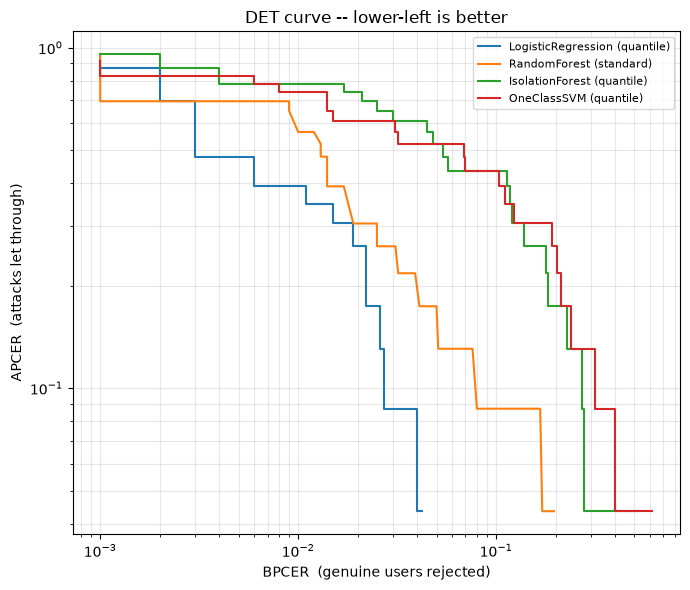

In [15]:
# The full trade-off rather than four points on it -- the standard PAD presentation.
# Log axes because the interesting region is the low-BPCER corner, which a linear
# plot squashes into nothing.
def det_curve(s, y_true):
    order = np.unique(s)
    return (np.array([(s[y_true == 0] > t).mean() for t in order]),
            np.array([(s[y_true == 1] <= t).mean() for t in order]))


fig, ax = plt.subplots(figsize=(7, 6))
for scaler_name, model_name in [("quantile", "LogisticRegression [sup, linear]"),
                                ("standard", "RandomForest [sup, non-lin]"),
                                ("quantile", "IsolationForest [1-class, non-lin]"),
                                ("quantile", "OneClassSVM [1-class, non-lin]")]:
    make_model, one_class = build_models(SCALERS[scaler_name])[model_name]
    s = out_of_fold_scores(make_model, df[list(FEATURES)].to_numpy(), y, one_class)
    b, a = det_curve(s, y)
    keep = (b > 0) & (a > 0)  # log axes can't show zeros
    ax.plot(b[keep], a[keep], label=f"{model_name.split(' [')[0]} ({scaler_name})")

ax.set(xscale="log", yscale="log", xlabel="BPCER  (genuine users rejected)",
       ylabel="APCER  (attacks let through)", title="DET curve -- lower-left is better")
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=8)
plt.tight_layout()

**`BPCER actual` is the honest check** — it should land near the target but not exactly on
it, since it's now measured on bona fide the threshold never saw.

**Note the asymmetry in the two intervals.** BPCER rests on ~500 held-out images, so it's
tight. APCER rests on 23, so it stays wide no matter how good the point estimate looks.
Any claim about attack detection is therefore much softer than any claim about user
friction.

## 12. Is the headline number stable?

The difference between missing 1 attack and missing 3 is *a single image landing in a
different fold*. A single seed's APCER is one draw from a distribution, not a result — so
here is the distribution.

This uncertainty is **additional to** Clopper-Pearson: the CI answers "we only have 23
attacks", the seed range answers "and the split matters too".

In [16]:
def stability_check(feature_names, scaler, model_name, n_seeds=20, bpcer_target=0.05):
    """Re-run the whole CV under n_seeds fold assignments; everything else fixed."""
    make_model, one_class = build_models(scaler)[model_name]
    X = df[feature_names].to_numpy()
    n_attacks = int((y == 1).sum())

    aucs, missed = [], []
    for seed in range(n_seeds):
        s = out_of_fold_scores(make_model, X, y, one_class, seed=seed)
        threshold = np.percentile(s[y == 0], 100 * (1 - bpcer_target))
        missed.append(int((s[y == 1] <= threshold).sum()))
        aucs.append(roc_auc_score(y, s))

    return {"model": model_name, "AUC med": np.median(aucs),
            "AUC range": f"[{min(aucs):.3f}, {max(aucs):.3f}]",
            "missed med": int(np.median(missed)),
            "missed range": f"{min(missed)}-{max(missed)} / {n_attacks}",
            "APCER med": np.median(missed) / n_attacks}


CONTENDERS = [("quantile", "LogisticRegression [sup, linear]"),
              ("standard", "RandomForest [sup, non-lin]"),
              ("quantile", "IsolationForest [1-class, non-lin]"),
              ("quantile", "OneClassSVM [1-class, non-lin]")]

pd.DataFrame([
    {"scaler": sc, **stability_check(list(FEATURES), SCALERS[sc], m)}
    for sc, m in CONTENDERS
]).set_index(["model", "scaler"]).round(3)

,,AUC med,AUC range,missed med,missed range,APCER med
model,scaler,,,,,
"LogisticRegression [sup, linear]",quantile,0.989,"[0.970, 0.991]",1,0-3 / 23,0.043
"RandomForest [sup, non-lin]",standard,0.976,"[0.966, 0.983]",3,1-5 / 23,0.130
"IsolationForest [1-class, non-lin]",quantile,0.898,"[0.892, 0.910]",10,9-12 / 23,0.457
"OneClassSVM [1-class, non-lin]",quantile,0.878,"[0.866, 0.893]",13,10-13 / 23,0.565


Quote the **median with the range**, never the best seed. A model whose `missed range` spans
several images is telling us its apparent advantage is partly luck of the split. Confirms logisitic regression again.

## 13. Check the coefficients to see what's weighted the most by the model.

The specific thing being checked: `specular_ratio` and `glare_area` separate *backwards*
(screens show less glare). If they carry large coefficients, i may have built a
camera-distance detector rather than a screen detector.

In [17]:
from sklearn.pipeline import Pipeline

pipe = make_pipeline(SCALERS["quantile"](),
                     LogisticRegression(class_weight="balanced", max_iter=1000))
pipe.fit(df[list(FEATURES)].to_numpy(), y)

coefs = pd.DataFrame({
    "coefficient": pipe[-1].coef_[0],
    "cliffs_delta": [sep.loc[f, "cliffs_delta"] for f in FEATURES],
}, index=list(FEATURES))
coefs["abs"] = coefs["coefficient"].abs()
# Sign agreement is the sanity check: a feature whose coefficient points the opposite
# way to its univariate delta is doing something only-in-combination, which is worth
# understanding rather than assuming is fine.
coefs["sign_agrees"] = np.sign(coefs["coefficient"]) == np.sign(coefs["cliffs_delta"])
coefs.sort_values("abs", ascending=False).drop(columns="abs").round(3)

,coefficient,cliffs_delta,sign_agrees
noise,4.403,0.750,True
perpendicular_ratio,1.670,0.490,True
hf_energy,-1.619,0.377,False
chroma_std,1.432,0.410,True
prewitt_energy,1.408,0.518,True
glare_area,-1.041,-0.314,True
line_ratio,0.749,0.576,True
sharpness,-0.487,0.695,False
orientation_entropy,-0.436,-0.607,True
colorfulness,-0.358,0.262,False


---

## 14. Collinearity and regularisation

13 turned up something that needs resolving before shipping: **three features have
coefficients whose sign disagrees with their univariate direction.** The clearest is
`sharpness` — Cliff's delta +0.695 (attacks score higher) but coefficient −0.487 (the
model treats higher values as *less* attack-like).

That isn't necessarily wrong. It's the signature of a **suppressor variable**: when two
features are correlated, one can flip sign to correct the other's overshoot, and the pair
still predicts well together. But it has two costs:

1. **The model becomes uninterpretable feature-by-feature.** We can no longer say "higher
   sharpness means attack", which undermines the whole reason for choosing a linear model.
2. **Coefficients become unstable.** With correlated inputs, which feature gets the large
   weight is partly arbitrary and can swing between folds.

`sharpness` and `noise` are the prime suspects: both are Laplacian-derived (variance of
the Laplacian, and Immerkær's estimator which uses a Laplacian-like kernel), so they are
close to measuring one quantity twice.

Nothing here has been tuned, either - still got `C=1.0` with L2 is an untested default.

In [18]:
# Diagnose on the quantile-transformed features, since that is what the model
# actually sees -- the transform is monotone per feature but it does change the
# linear correlation structure.
Xq = SCALERS["quantile"]().fit_transform(df[list(FEATURES)].to_numpy())
corr_q = np.corrcoef(Xq, rowvar=False)

# VIF_i = 1/(1 - R^2_i) from regressing feature i on all others, which is exactly
# the i-th diagonal entry of the inverted correlation matrix.
vif = pd.Series(np.diag(np.linalg.inv(corr_q)), index=list(FEATURES))
print("Variance inflation factors (>5 usually called problematic, >10 severe):")
print(vif.sort_values(ascending=False).round(2).to_string())

# Condition number: how close the design matrix is to singular. Large values mean
# coefficients are poorly determined even if predictions are fine.
print(f"\ncondition number of the correlation matrix: {np.linalg.cond(corr_q):.1f}")

print("\nmost correlated pairs:")
names = list(FEATURES)
pairs = [(names[i], names[j], corr_q[i, j])
         for i in range(len(names)) for j in range(i + 1, len(names))]
for a, b, r in sorted(pairs, key=lambda t: -abs(t[2]))[:6]:
    print(f"  {r:+.3f}  {a} <-> {b}")

Variance inflation factors (>5 usually called problematic, >10 severe):
specular_ratio         30.43
glare_area             29.60
sharpness              12.49
chroma_std              6.67
colorfulness            6.40
noise                   4.63
hf_energy               4.04
prewitt_energy          3.45
perpendicular_ratio     1.42
line_ratio              1.41
orientation_entropy     1.38

condition number of the correlation matrix: 201.4

most correlated pairs:
  +0.982  specular_ratio <-> glare_area
  +0.913  colorfulness <-> chroma_std
  +0.838  sharpness <-> hf_energy
  +0.796  sharpness <-> noise
  +0.682  sharpness <-> prewitt_energy
  +0.642  noise <-> hf_energy


### Comparing regularisation - with tuning

The trap here is tuning `C` on the same folds used to report performance: that leaks, and
inflates the result by exactly the amount the tuning overfits. So this uses **nested
cross-validation** — an inner loop picks `C` using only the outer training fold, and the
outer loop reports performance on data neither the model nor the hyperparameter search has
seen.

That matters more than usual at n=23. Hyperparameter selection is itself a fitting
procedure, and with this few positives it can overfit readily, so the *selected* `C` may
be unstable even where the performance estimate is sound. Both are reported: the honest
performance, and which `C` values actually got picked across folds and seeds.

Four candidates against the current default:

- **no regularisation** — the unconstrained fit, as a reference point
- **L2 tuned** — shrinks correlated coefficients *together* rather than picking arbitrarily
  between them, which is the textbook response to collinearity
- **L1 tuned** — drives redundant coefficients to exactly zero, so it doubles as principled
  feature selection and directly addresses the `sharpness`/`noise` pair
- **ElasticNet tuned** — both, for when neither alone is right

In [19]:
# GridSearchCV wraps the inner tuning loop; everything else is already imported.
from sklearn.model_selection import GridSearchCV

X_all = df[list(FEATURES)].to_numpy()


def apcer_at_bpcer(scores, target):
    """Threshold from bona fide only, as everywhere else."""
    thr = np.percentile(scores[y == 0], 100 * (1 - target))
    return (scores[y == 1] <= thr).mean()


def nested_scores(estimator, param_grid, seed=0, n_outer=5, n_inner=4):
    """Outer loop estimates performance; inner loop picks the hyperparameter.

    Selecting C inside the outer training fold only. Tuning on the same data used
    to report performance would leak and inflate the result.
    """
    scores = np.empty(len(y))
    chosen = []
    outer = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=seed)
    for tr, te in outer.split(X_all, y):
        if param_grid:
            search = GridSearchCV(
                estimator, param_grid, scoring="roc_auc", n_jobs=-1,
                cv=StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=seed),
            )
            search.fit(X_all[tr], y[tr])
            fitted, params = search.best_estimator_, search.best_params_
            chosen.append(params.get("logisticregression__C"))
        else:
            fitted = estimator.fit(X_all[tr], y[tr])
        scores[te] = fitted.predict_proba(X_all[te])[:, 1]
    return scores, chosen


def lr(**kw):
    return make_pipeline(SCALERS["quantile"](),
                         LogisticRegression(class_weight="balanced", max_iter=5000, **kw))


CS = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
CANDIDATES = {
    "current (L2, C=1, untuned)": (lr(), {}),
    "no regularisation": (lr(penalty=None), {}),
    "L2 tuned": (lr(), {"logisticregression__C": CS}),
    "L1 tuned": (lr(penalty="l1", solver="liblinear"), {"logisticregression__C": CS}),
    "ElasticNet tuned": (lr(penalty="elasticnet", solver="saga"),
                         {"logisticregression__C": CS,
                          "logisticregression__l1_ratio": [0.2, 0.5, 0.8]}),
}

rows = []
for name, (est, grid) in CANDIDATES.items():
    per_seed, picks = [], []
    for seed in (0, 1, 2):  # 3 seeds, since one fold split is one draw
        s, chosen = nested_scores(est, grid, seed=seed)
        per_seed.append((roc_auc_score(y, s), apcer_at_bpcer(s, 0.01), apcer_at_bpcer(s, 0.05)))
        picks += chosen
    arr = np.array(per_seed)
    rows.append({"model": name, "AUC": arr[:, 0].mean(),
                 "APCER@1%": arr[:, 1].mean(),
                 "APCER@1% range": f"[{arr[:, 1].min():.2f}, {arr[:, 1].max():.2f}]",
                 "APCER@5%": arr[:, 2].mean(),
                 "C picked": (f"{min(picks)}-{max(picks)}" if picks else "-")})

pd.DataFrame(rows).set_index("model").round(3)

/home/ow25/miniconda3/envs/iproov-oliver-whitehead/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ow25/miniconda3/envs/iproov-oliver-whitehead/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  w

,AUC,APCER@1%,APCER@1% range,APCER@5%,C picked
model,,,,,
"current (L2, C=1, untuned)",0.988,0.362,"[0.35, 0.39]",0.043,-
no regularisation,0.985,0.348,"[0.30, 0.39]",0.087,-
L2 tuned,0.972,0.319,"[0.30, 0.35]",0.130,0.01-100.0
L1 tuned,0.976,0.406,"[0.35, 0.43]",0.101,0.1-100.0
ElasticNet tuned,0.978,0.406,"[0.35, 0.43]",0.116,0.1-100.0


In [20]:
# What does L1 actually discard, and does dropping a collinear partner by hand
# match what L1 does automatically?
print("L1 feature selection, fitted on all data:")
for C in [0.01, 0.1, 1.0]:
    m = lr(penalty="l1", solver="liblinear", C=C).fit(X_all, y)
    coef = m[-1].coef_[0]
    kept = [f for f, c in zip(FEATURES, coef) if abs(c) > 1e-6]
    print(f"  C={C:<6} keeps {len(kept):2d}/{len(FEATURES)}: {kept}")

print("\nAblation -- drop one feature, keep everything else fixed:")
for drop in [None, "sharpness", "noise", "hf_energy", "colorfulness"]:
    feats = [f for f in FEATURES if f != drop]
    Xa = df[feats].to_numpy()
    s = np.empty(len(y))
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=0).split(Xa, y):
        m = lr().fit(Xa[tr], y[tr])
        s[te] = m.predict_proba(Xa[te])[:, 1]
    print(f"  drop {str(drop):16s} AUC {roc_auc_score(y, s):.4f}   "
          f"APCER@1% {apcer_at_bpcer(s, 0.01):.3f}   APCER@5% {apcer_at_bpcer(s, 0.05):.3f}")

L1 feature selection, fitted on all data:
  C=0.01   keeps  4/11: ['noise', 'glare_area', 'line_ratio', 'perpendicular_ratio']


/home/ow25/miniconda3/envs/iproov-oliver-whitehead/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ow25/miniconda3/envs/iproov-oliver-whitehead/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/ow25/miniconda3/envs/iproov-oliver-whitehead/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

  C=0.1    keeps  8/11: ['noise', 'chroma_std', 'glare_area', 'line_ratio', 'hf_energy', 'prewitt_energy', 'orientation_entropy', 'perpendicular_ratio']
  C=1.0    keeps 10/11: ['sharpness', 'noise', 'colorfulness', 'chroma_std', 'glare_area', 'line_ratio', 'hf_energy', 'prewitt_energy', 'orientation_entropy', 'perpendicular_ratio']

Ablation -- drop one feature, keep everything else fixed:


/home/ow25/miniconda3/envs/iproov-oliver-whitehead/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ow25/miniconda3/envs/iproov-oliver-whitehead/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


  drop None             AUC 0.9887   APCER@1% 0.391   APCER@5% 0.000
  drop sharpness        AUC 0.9886   APCER@1% 0.391   APCER@5% 0.000
  drop noise            AUC 0.9433   APCER@1% 0.652   APCER@5% 0.174
  drop hf_energy        AUC 0.9834   APCER@1% 0.522   APCER@5% 0.087
  drop colorfulness     AUC 0.9892   APCER@1% 0.348   APCER@5% 0.000


In [ ]:
# Do the sign disagreements survive regularisation? This is the interpretability
# question rather than the performance one - a model we can read is worth
# something on its own.
comparison = pd.DataFrame({"cliffs_delta": [sep.loc[f, "cliffs_delta"] for f in FEATURES]},
                          index=list(FEATURES))
for label, model in [("L2 C=1", lr()),
                     ("L2 C=0.01", lr(C=0.01)),
                     ("L1 C=0.1", lr(penalty="l1", solver="liblinear", C=0.1))]:
    comparison[label] = model.fit(X_all, y)[-1].coef_[0]

for label in [c for c in comparison.columns if c != "cliffs_delta"]:
    agree = np.sign(comparison[label]) == np.sign(comparison["cliffs_delta"])
    disagreeing = list(comparison.index[~agree & (comparison[label].abs() > 1e-6)])
    print(f"{label:12s} sign disagreements: {disagreeing or 'none'}")

comparison.round(3)

L2 C=1       sign disagreements: ['sharpness', 'colorfulness', 'hf_energy']
L2 C=0.01    sign disagreements: ['hf_energy']
L1 C=0.1     sign disagreements: ['hf_energy']


/home/ow25/miniconda3/envs/iproov-oliver-whitehead/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ow25/miniconda3/envs/iproov-oliver-whitehead/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,cliffs_delta,L2 C=1,L2 C=0.01,L1 C=0.1
sharpness,0.695,-0.487,0.322,0.000
noise,0.750,4.403,0.728,2.081
colorfulness,0.262,-0.358,0.118,0.000
chroma_std,0.410,1.432,0.319,0.589
specular_ratio,-0.243,-0.045,-0.249,0.000
glare_area,-0.314,-1.041,-0.307,-0.607
line_ratio,0.576,0.749,0.409,0.538
hf_energy,0.377,-1.619,-0.139,-0.595
prewitt_energy,0.518,1.408,0.254,0.426
orientation_entropy,-0.607,-0.436,-0.363,-0.271


### Decision

Three things to weigh, and they don't automatically point the same way:

- **Performance.** If nested CV shows tuned regularisation beating the untuned default on
  APCER@1%, that's a straightforward win. If it's within noise (likely, since the ranges
  across seeds are wide at n=23) then performance isn't the deciding factor.
- **Interpretability.** If a stronger penalty removes the sign disagreements, the
  coefficients become quotable again. That's worth a small performance cost.
- **Honesty about selection.** The `C picked` column shows wildly different values
  across folds, the tuning is itself unstable.

The ablation is the cross-check: if dropping `sharpness` costs nothing, then it was
genuinely redundant with `noise` and the honest move is to drop it outright rather than
keep a feature whose coefficient we can't interpret.

---

## 14. The shipped model

Everything above analyses the **11-feature** set, which is what the investigation was
carried out on and what section 13 needed in order to show *why* three features were cut. The
model that actually ships uses the surviving **eight**.

This section closes that gap: it fits the shipped configuration, reports its numbers, and
verifies they match `artefacts/config.json` — so the notebook, the report and the deployed
artefact cannot silently disagree.

Dropped, on converging evidence from VIF, ablation, L1 selection and coefficient-sign
stability (section 13):

| dropped | why |
|---|---|
| `sharpness` | VIF 12.5; r=0.80 with `noise`, 0.84 with `hf_energy`. Ablation cost: AUC 0.0001 — free |
| `colorfulness` | r=0.91 with `chroma_std`. Dropping it *improved* APCER@1% |
| `specular_ratio` | r=0.98 with `glare_area` — both derive from the same bright-desaturated mask, so never independent |

In [ ]:
SHIPPED = [
    "noise", "chroma_std", "glare_area", "line_ratio",
    "hf_energy", "prewitt_energy", "orientation_entropy", "perpendicular_ratio",
]  # no longer the shipped values look in patch_analysis.ipynb for additional features.

X_ship = df[SHIPPED].to_numpy()


def oof(feats, seed):
    X = df[feats].to_numpy()
    s = np.empty(len(y))
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=seed).split(X, y):
        s[te] = lr().fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
    return s


# 10 seeds, because a single fold split is one draw and at n=23 the spread matters
rows = []
for name, feats in [("11 (investigated)", list(FEATURES)), ("8 (shipped)", SHIPPED)]:
    au, a1, a5 = [], [], []
    for seed in range(10):
        s = oof(feats, seed)
        au.append(roc_auc_score(y, s))
        a1.append(apcer_at_bpcer(s, 0.01))
        a5.append(apcer_at_bpcer(s, 0.05))
    rows.append({"feature set": name, "AUC": np.mean(au),
                 "APCER@1%": np.mean(a1), "APCER@1% range": f"[{min(a1):.2f}, {max(a1):.2f}]",
                 "APCER@5%": np.mean(a5), "APCER@5% range": f"[{min(a5):.2f}, {max(a5):.2f}]"})

print("Cutting features improved every metric AND tightened the spread:")
print(pd.DataFrame(rows).set_index("feature set").round(4).to_string())

Xq_ship = SCALERS["quantile"]().fit_transform(X_ship)
corr_ship = np.corrcoef(Xq_ship, rowvar=False)
print(f"\nmax VIF {np.diag(np.linalg.inv(corr_ship)).max():.2f} (was 30.4), "
      f"condition number {np.linalg.cond(corr_ship):.1f} (was 201)")

Cutting features improved every metric AND tightened the spread:
                      AUC  APCER@1% APCER@1% range  APCER@5% APCER@5% range
feature set                                                                
11 (investigated)  0.9880    0.3435   [0.26, 0.39]    0.0435   [0.00, 0.13]
8 (shipped)        0.9894    0.2913   [0.22, 0.35]    0.0217   [0.00, 0.04]

max VIF 2.49 (was 30.4), condition number 10.1 (was 201)


In [ ]:
# Coefficients of the model. Seven of eight now agree in sign with their
# univariate direction, so they can be read individually - which was the point
# of preferring a linear model in the first place.
shipped_model = lr().fit(X_ship, y)
coefs_ship = pd.DataFrame({
    "coefficient": shipped_model[-1].coef_[0],
    "cliffs_delta": [sep.loc[f, "cliffs_delta"] for f in SHIPPED],
}, index=SHIPPED)
coefs_ship["sign_agrees"] = (
    np.sign(coefs_ship["coefficient"]) == np.sign(coefs_ship["cliffs_delta"])
)
print(coefs_ship.reindex(coefs_ship["coefficient"].abs().sort_values(ascending=False).index)
      .round(3).to_string())

disagreeing = list(coefs_ship.index[~coefs_ship["sign_agrees"]])
print(f"\nsign disagreements: {disagreeing}")

                     coefficient  cliffs_delta  sign_agrees
noise                      4.299         0.750         True
hf_energy                 -1.821         0.377        False
perpendicular_ratio        1.698         0.490         True
prewitt_energy             1.293         0.518         True
chroma_std                 1.099         0.410         True
glare_area                -1.094        -0.314         True
line_ratio                 0.690         0.576         True
orientation_entropy       -0.393        -0.607         True

sign disagreements: ['hf_energy']


hf_energy is a genuine suppressor, not a collinearity artefact - it is a *ratio*
(what fraction of spectral energy is high-frequency) while noise and prewitt_energy are absolute magnitudes, so its residual role can invert. It stays because removing it makes APCER@5% four times worse (0.022 -> 0.096).

## 15. Conclusions

**What is established.**

- **Resolution was a severe confound** — all bona fide 1024², all attacks larger — and is
  neutralised by resizing everything before measurement. Catching this was worth more than
  any modelling decision that followed; without it every number would have been measuring
  image dimensions.
- **Edge orientation was the most valuable feature idea**, and it came from asking what the
  artefact physically *is* (a rectangular frame concentrates edges at two perpendicular
  angles) rather than from trying more texture statistics. Attacks missed fell 7→4 when the
  orientation pair was added.
- **Preprocessing mattered more than model choice.** Rank-based scaling made a *linear*
  model the best performer, beating random forests and every one-class alternative. The
  simplest option is also the best one, and its coefficients are readable.
- **Cutting features improved the model.** Eight beat eleven on every metric, with max VIF
  falling 30.4 → 2.49. Four independent tests agreed on which three to remove.
- **Regularisation did not help**, and the tuning was unstable across folds (C selected
  over four orders of magnitude). Documented as a deliberate choice rather than an omission.

**What is not established, and cannot be with this data.**

- **Generalisation to any unseen attack instrument.** All 23 attacks are one device. This
  is the dominant limitation and no amount of modelling fixes it.
- **Any APCER to better than roughly ±15 points.** Even a perfect 0/23 carries a
  Clopper-Pearson interval of [0.00, 0.15].
- **Whether the supervised advantage is real or memorisation.** It sees attack labels; the
  one-class models don't and do worse. With one device behind the attacks, that gap cannot
  be attributed confidently.

**The operating point is the result, not a single number.** At 5% BPCER the model catches
every attack; at a deployable 1% it misses roughly a third. Quoting the 5% figure alone
would materially overstate the method.